# NorthStar Urban Mobility — Python Data Processing
**Tools:** Pandas · NumPy · Matplotlib

## 1. Load the Dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Define the base path once
url = "https://raw.githubusercontent.com/adamandreea0702-sys/NorthStar-Analytics/main/data/northstar_dataset.csv/"

# Load all CSV files in one loop
files = ["customers", "orders", "deliveries", "drivers", "vehicles",
         "hubs", "incidents", "complaints", "app_events"]

for f in files:
    globals()[f] = pd.read_csv(url + f + ".csv")

print("Files loaded successfully.")
deliveries.head()

Files loaded successfully.


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


## 2. Understand the Data Structure

In [22]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [23]:
deliveries.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950.000000,950.000000,950.000000,936.000000,950.000000
mean,13.909316,0.969474,0.072632,3.864679,12.841295
std,7.477907,1.093189,0.259667,0.894420,4.336468
min,1.200000,0.000000,0.000000,1.000000,2.500000
25%,9.135000,0.000000,0.000000,3.360000,9.925000
50%,12.840000,1.000000,0.000000,4.040000,12.645000
75%,16.835000,2.000000,0.000000,4.550000,15.697500
max,41.940000,7.000000,1.000000,5.000000,29.430000


## 3. Data Quality Assessment

In [24]:
# Check missing values
missing = deliveries.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64


In [25]:
# Check duplicate rows
print("Duplicate rows:", deliveries.duplicated().sum())

Duplicate rows: 0


In [26]:
# Check unique zone values — zone names are inconsistent across files
print("Unique zones in orders:")
print(sorted(orders["pickup_zone"].dropna().unique()))

Unique zones in orders:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


## 4. Data Cleaning

In [27]:
# Standardise zone names — 16 inconsistent spellings found across all files
ZONE_MAP = {
    'AIRPORT':'Airport', 'Airport':'Airport',
    'NORTH':'North', 'North':'North', 'north':'North',
    'SOUTH':'South', 'South':'South',
    'EAST':'East', 'EAST':'East',
    'WEST':'West', 'WEST':'West',
    'CENTRAL':'Central', 'Central':'Central', 'Ctr':'Central',
    'RiverSide':'Riverside', 'Riverside':'Riverside'
}

customers["home_zone"]     = customers["home_zone"].map(ZONE_MAP)
orders["pickup_zone"]      = orders["pickup_zone"].map(ZONE_MAP)
orders["dropoff_zone"]     = orders["dropoff_zone"].map(ZONE_MAP)
drivers["base_zone"]       = drivers["base_zone"].map(ZONE_MAP)
vehicles["assigned_zone"]  = vehicles["assigned_zone"].map(ZONE_MAP)
app_events["zone_context"] = app_events["zone_context"].map(ZONE_MAP)

print("Zone standardisation complete.")
print("Unique zones after cleaning:", sorted(orders["pickup_zone"].dropna().unique()))

Zone standardisation complete.
Unique zones after cleaning: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [28]:
# Parse datetime columns
deliveries["dispatch_time"]         = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")

print("Datetime columns parsed.")

Datetime columns parsed.


In [29]:
# Impute missing values with median
deliveries["customer_rating_post_delivery"].fillna(deliveries["customer_rating_post_delivery"].median(), inplace=True)
drivers["training_score"].fillna(drivers["training_score"].median(), inplace=True)
vehicles["battery_health_pct"].fillna(vehicles["battery_health_pct"].median(), inplace=True)
customers["loyalty_score"].fillna(customers["loyalty_score"].median(), inplace=True)
customers["preferred_channel"].fillna("Unknown", inplace=True)
orders["booking_channel"].fillna("Unknown", inplace=True)

print("Missing values imputed.")
print("Remaining nulls in deliveries:", deliveries.isnull().sum().sum())

Missing values imputed.
Remaining nulls in deliveries: 19


/tmp/ipykernel_14551/3763100220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries["customer_rating_post_delivery"].fillna(deliveries["customer_rating_post_delivery"].median(), inplace=True)
/tmp/ipykernel_14551/3763100220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

## 5. Feature Engineering

In [30]:
# Compute delivery duration in hours
deliveries["duration_hours"] = (
    (deliveries["delivery_completed_at"] - deliveries["dispatch_time"])
    .dt.total_seconds() / 3600
).abs()

# Binary outcome flags
deliveries["is_failed"]  = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)

# High-risk customer flag — 2 or more complaints
complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
customers = customers.merge(complaint_counts, on="customer_id", how="left")
customers["complaint_count"].fillna(0, inplace=True)
customers["high_risk"] = (customers["complaint_count"] >= 2).astype(int)

print("Features created.")
print("High-risk customers:", customers["high_risk"].sum())

Features created.
High-risk customers: 74


/tmp/ipykernel_14551/3103368232.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["complaint_count"].fillna(0, inplace=True)


## 6. NumPy Statistical Analysis

In [31]:
# Delivery duration statistics using NumPy
durations = deliveries["duration_hours"].dropna().values

print("Delivery Duration Statistics:")
print("  Mean     :", np.mean(durations).round(2), "hours")
print("  Median   :", np.median(durations).round(2), "hours")
print("  Std Dev  :", np.std(durations).round(2), "hours")
print("  90th pct :", np.percentile(durations, 90).round(2), "hours")
print("  Max      :", np.max(durations).round(2), "hours")

Delivery Duration Statistics:
  Mean     : 9.67 hours
  Median   : 7.07 hours
  Std Dev  : 8.5 hours
  90th pct : 22.21 hours
  Max      : 43.46 hours


In [32]:
# Manual override statistics
overrides = deliveries["manual_route_override_count"].values

print("Manual Route Override Statistics:")
print("  Mean     :", np.mean(overrides).round(3))
print("  Variance :", np.var(overrides).round(3))
print("  75th pct :", np.percentile(overrides, 75))

Manual Route Override Statistics:
  Mean     : 0.969
  Variance : 1.194
  75th pct : 2.0


In [33]:
# Build master dataframe for analysis
master = deliveries.merge(
    orders[["order_id","pickup_zone","service_type","promised_window_hours","order_value"]],
    on="order_id", how="left")
master = master.merge(
    drivers[["driver_id","training_score","driver_rating","years_experience"]],
    on="driver_id", how="left")
master = master.merge(
    vehicles[["vehicle_id","battery_health_pct","maintenance_status"]],
    on="vehicle_id", how="left")

# NumPy correlation: overrides vs customer rating
x = master["manual_route_override_count"].dropna().values
y = master["customer_rating_post_delivery"].dropna().values
n = min(len(x), len(y))
corr = np.corrcoef(x[:n], y[:n])[0, 1]
print("Correlation — overrides vs customer rating:", round(corr, 4))

Correlation — overrides vs customer rating: -0.0598


## 7. Visual Insights

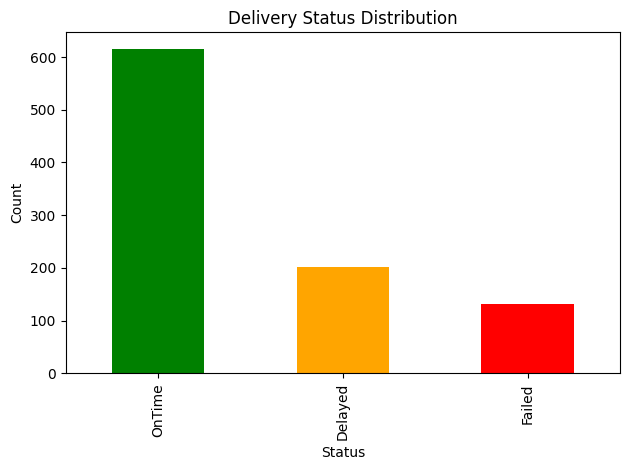

In [34]:
# Delivery status distribution
deliveries["delivery_status"].value_counts().plot(kind="bar", color=["green","orange","red"])
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

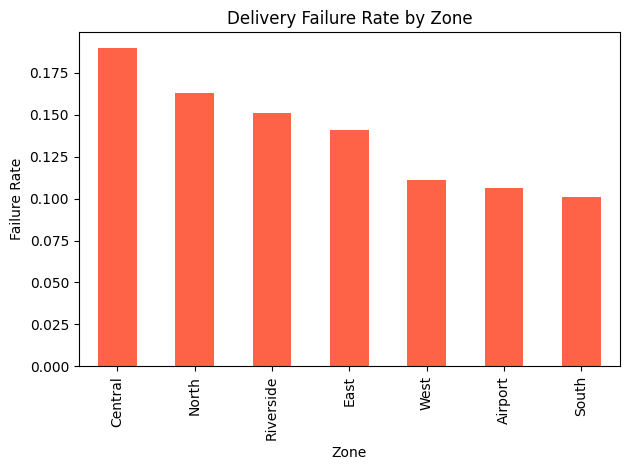

pickup_zone
Central      0.190
North        0.163
Riverside    0.151
East         0.141
West         0.111
Airport      0.106
South        0.101
Name: is_failed, dtype: float64


In [35]:
# Failure rate by zone
zone_perf = master.groupby("pickup_zone")["is_failed"].mean().sort_values(ascending=False)
zone_perf.plot(kind="bar", color="tomato")
plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure Rate")
plt.tight_layout()
plt.show()

print(zone_perf.round(3))

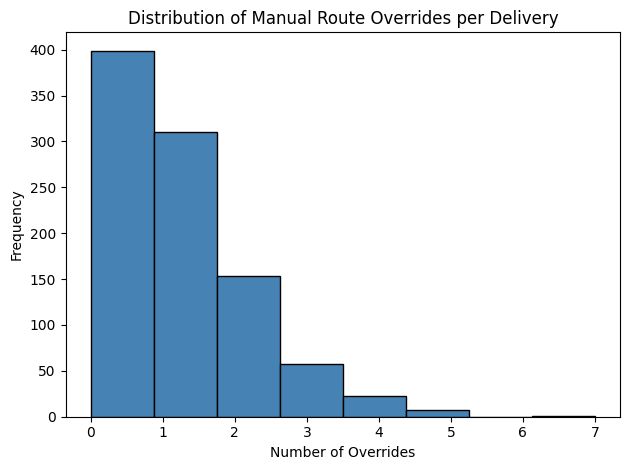

In [36]:
# Manual route overrides distribution
deliveries["manual_route_override_count"].plot(kind="hist", bins=8, color="steelblue", edgecolor="black")
plt.title("Distribution of Manual Route Overrides per Delivery")
plt.xlabel("Number of Overrides")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

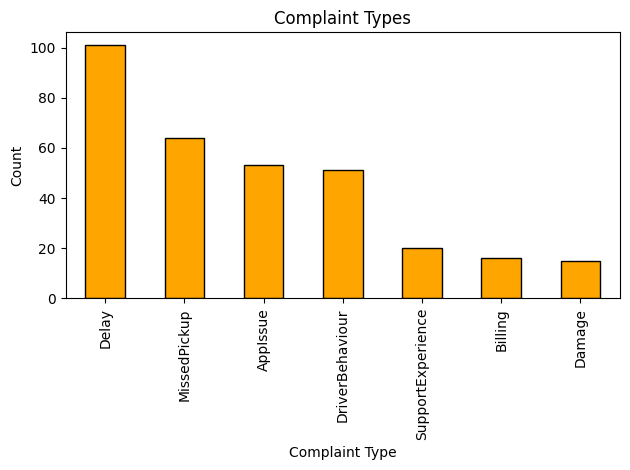

In [37]:
# Complaint types
complaints["complaint_type"].value_counts().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
# Ghost-completed problem — complaints against OnTime deliveries
comp_del = complaints.merge(deliveries[["order_id","delivery_status"]], on="order_id", how="left")
ghost    = comp_del[comp_del["delivery_status"] == "OnTime"]

print("Total complaints:", len(complaints))
print("Complaints against OnTime deliveries:", len(ghost),
      "(" + str(round(100*len(ghost)/len(complaints), 1)) + "%)")
print()
print(ghost["complaint_type"].value_counts())

Total complaints: 320
Complaints against OnTime deliveries: 149 (46.6%)

complaint_type
Delay                44
DriverBehaviour      29
AppIssue             25
MissedPickup         25
SupportExperience    11
Damage                8
Billing               7
Name: count, dtype: int64


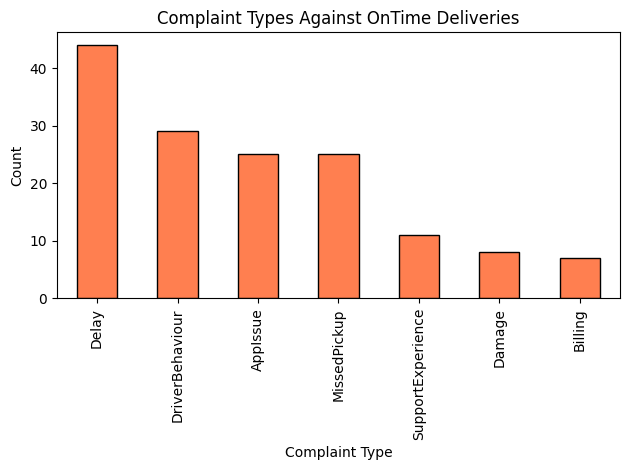

In [39]:
# Ghost-completed chart
ghost["complaint_type"].value_counts().plot(kind="bar", color="coral", edgecolor="black")
plt.title("Complaint Types Against OnTime Deliveries")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 8. Business Insights

In [40]:
print("KEY FINDINGS")
print("=" * 50)
print("Zone with highest failure rate:", master.groupby("pickup_zone")["is_failed"].mean().idxmax())
print("Zone with lowest failure rate: ", master.groupby("pickup_zone")["is_failed"].mean().idxmin())
print("Ghost-completed complaints:    ", len(ghost), "(" + str(round(100*len(ghost)/len(complaints),1)) + "%)")
print("High-risk customers:           ", int(customers["high_risk"].sum()))
print("Avg overrides per delivery:    ", round(float(np.mean(overrides)), 2))
print("Avg delivery duration (hrs):   ", round(float(np.mean(durations)), 2))

KEY FINDINGS
Zone with highest failure rate: Central
Zone with lowest failure rate:  South
Ghost-completed complaints:     149 (46.6%)
High-risk customers:            74
Avg overrides per delivery:     0.97
Avg delivery duration (hrs):    9.67
